# Energy Performance Certificates (DPE) vs Real Electricity Consumption Analysis

**Enedis Challenge - Open Data University**

## Objectives:
1. Compare DPE estimated consumption vs real measured consumption
2. Quantify savings when improving energy class (G→F, F→E, etc.)
3. Analyze variability due to individual behaviors

## Data:
- Simulated Enedis consumption data
- Simulated DPE data (based on ADEME methodology)
- Analysis limited to addresses with ≥10 dwellings

**Author:** Belén Vera Maric
**Date:** 05/06/2026

## Import libraries and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('MERGED_DPE_enedis.csv')
print("Data loaded successfully")
print(f"Records: {len(df):,}")
print(f"Columns: {len(df.columns)}")

Data loaded successfully
Records: 77,815
Columns: 37


In [6]:
# Create analysis variables

# DPE class (already exists as 'etiquette_dpe')
df['dpe_class'] = df['etiquette_dpe']

# Theoretical consumption (kWh/m²) 
df['consumption_theoretical'] = df['conso_5_usages_par_m2_ef']

# Real consumption (kWh/m²) - from Enedis data
# Column is in MWh, convert to kWh/m²
df['consumption_real'] = df["Consommation annuelle moyenne par logement de l'adresse (MWh)"] * 1000 / df['surface_habitable_logement']

# Calculate difference and relative error
df['difference'] = df['consumption_real'] - df['consumption_theoretical']
df['relative_error'] = (df['difference'] / df['consumption_theoretical']) * 100

# Filter valid DPE classes (A-G)
valid_classes = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
df = df[df['dpe_class'].isin(valid_classes)]

print(f"After filtering: {len(df):,} rows")
print(f"Consumption theoretical - mean: {df['consumption_theoretical'].mean():.1f} kWh/m²")
print(f"Consumption real - mean: {df['consumption_real'].mean():.1f} kWh/m²")

After filtering: 77,815 rows
Consumption theoretical - mean: 107.8 kWh/m²
Consumption real - mean: 80.5 kWh/m²


## Average consumption by DPE class


In [9]:
class_order = ['G', 'F', 'E', 'D', 'C', 'B', 'A']  

consumption_by_class = df.groupby('dpe_class').agg({
    'consumption_theoretical': 'mean',
    'consumption_real': 'mean',
    'surface_habitable_logement': 'count'
}).round(1)

consumption_by_class = consumption_by_class.reindex(class_order)

print("="*60)
print("AVERAGE CONSUMPTION BY DPE CLASS (kWh/m²/year)")
print("="*60)
print(consumption_by_class.to_string())

# Calculate savings when IMPROVING (going UP in class)
print("\n" + "="*60)
print("SAVINGS WHEN IMPROVING ONE DPE CLASS")
print("(Example: G→F, F→E, E→D, etc.)")
print("="*60)

savings_list = []
for i in range(len(class_order)-1):
    current = class_order[i]      # Worse class (e.g., G)
    better = class_order[i+1]     # Better class (e.g., F)
    
    if current in consumption_by_class.index and better in consumption_by_class.index:
        # Saving = consumption of worse class - consumption of better class
        saving_real = consumption_by_class.loc[current, 'consumption_real'] - consumption_by_class.loc[better, 'consumption_real']
        
        savings_list.append({
            'Improvement': f"{current} → {better}",
            'Saving (kWh/m²)': round(saving_real, 1)
        })

df_savings = pd.DataFrame(savings_list)
print(df_savings.to_string(index=False))

AVERAGE CONSUMPTION BY DPE CLASS (kWh/m²/year)
           consumption_theoretical  consumption_real  surface_habitable_logement
dpe_class                                                                       
G                            257.9             100.5                        3213
F                            175.7              89.6                        5500
E                            134.0              86.5                       16254
D                             97.8              82.3                       29332
C                             69.2              71.8                       20996
B                             40.7              46.7                        1903
A                             25.6              50.4                         617

SAVINGS WHEN IMPROVING ONE DPE CLASS
(Example: G→F, F→E, E→D, etc.)
Improvement  Saving (kWh/m²)
      G → F             10.9
      F → E              3.1
      E → D              4.2
      D → C             10.5
      C → 

## Convert to euros


In [11]:
# French electricity tariff 2026 (Tarif Bleu - Base)
TARIFF_BASE = 0.1940 # €/kWh

# Median surface area
median_surface = df['surface_habitable_logement'].median()

print("="*60)
print(f"ANNUAL SAVINGS IN EUROS ({median_surface:.0f}m² apartment)")
print(f"Tariff: {TARIFF_BASE} €/kWh")
print("="*60)

for _, row in df_savings.iterrows():
    saving_kwh_m2 = row['Saving (kWh/m²)']
    saving_kwh_total = saving_kwh_m2 * median_surface
    saving_euros = saving_kwh_total * TARIFF_BASE
    
    # CORRECTED: 'Improvement' instead of 'Transition'
    print(f"\n{row['Improvement']}:")
    print(f"   Saving: {saving_kwh_total:.0f} kWh/year")
    print(f"   Saving: {saving_euros:.0f} €/year")

ANNUAL SAVINGS IN EUROS (46m² apartment)
Tariff: 0.194 €/kWh

G → F:
   Saving: 504 kWh/year
   Saving: 98 €/year

F → E:
   Saving: 143 kWh/year
   Saving: 28 €/year

E → D:
   Saving: 194 kWh/year
   Saving: 38 €/year

D → C:
   Saving: 485 kWh/year
   Saving: 94 €/year

C → B:
   Saving: 1160 kWh/year
   Saving: 225 €/year

B → A:
   Saving: -171 kWh/year
   Saving: -33 €/year


## PE accuracy

In [13]:
print("="*60)
print("DO DPE ESTIMATES REFLECT REALITY?")
print("="*60)

print("\nGLOBAL STATISTICS:")
print(f"Mean theoretical consumption: {df['consumption_theoretical'].mean():.1f} kWh/m²")
print(f"Mean real consumption: {df['consumption_real'].mean():.1f} kWh/m²")
print(f"Mean difference (real - theoretical): {df['difference'].mean():.1f} kWh/m²")
print(f"Mean relative error: {df['relative_error'].mean():.1f}%")

# Statistical test
t_stat, p_value = stats.ttest_rel(df['consumption_theoretical'], df['consumption_real'])
print(f"\nPaired t-test (theoretical vs real):")
print(f"  p-value: {p_value:.4f}")

if p_value < 0.05:
    print("  → SIGNIFICANT difference: DPE does NOT perfectly reflect reality")
    if df['difference'].mean() > 0:
        print("  → DPE systematically UNDERESTIMATES real consumption")
    else:
        print("  → DPE systematically OVERESTIMATES real consumption")
else:
    print("  → No significant difference: DPE reflects reality well")

# By building type
print("\nBY BUILDING TYPE:")
for btype in df['type_batiment'].unique():
    subset = df[df['type_batiment'] == btype]
    print(f"\n  {btype} ({len(subset):,} dwellings):")
    print(f"    Theoretical: {subset['consumption_theoretical'].mean():.1f} kWh/m²")
    print(f"    Real: {subset['consumption_real'].mean():.1f} kWh/m²")
    print(f"    Difference: {subset['difference'].mean():.1f} kWh/m²")

DO DPE ESTIMATES REFLECT REALITY?

GLOBAL STATISTICS:
Mean theoretical consumption: 107.8 kWh/m²
Mean real consumption: 80.5 kWh/m²
Mean difference (real - theoretical): -27.3 kWh/m²
Mean relative error: -17.4%

Paired t-test (theoretical vs real):
  p-value: 0.0000
  → SIGNIFICANT difference: DPE does NOT perfectly reflect reality
  → DPE systematically OVERESTIMATES real consumption

BY BUILDING TYPE:

  appartement (74,664 dwellings):
    Theoretical: 108.4 kWh/m²
    Real: 81.3 kWh/m²
    Difference: -27.1 kWh/m²

  maison (3,148 dwellings):
    Theoretical: 93.6 kWh/m²
    Real: 61.2 kWh/m²
    Difference: -32.4 kWh/m²

  immeuble (3 dwellings):
    Theoretical: 103.4 kWh/m²
    Real: 2.2 kWh/m²
    Difference: -101.3 kWh/m²


## Variability due to lifestyle and occupancy

In [14]:
print("="*60)
print("VARIABILITY DUE TO LIFESTYLE & OCCUPANCY")
print("="*60)

# Standard deviation of error by DPE class
variability = df.groupby('dpe_class')['difference'].agg(['std', 'mean', 'count']).round(2)
variability = variability.reindex(class_order)
variability.columns = ['Std Dev (kWh/m²)', 'Mean Error (kWh/m²)', 'Number of dwellings']

print("\n Error variability by DPE class:")
print(variability)

print("\n INTERPRETATION:")
print("The standard deviation measures variability due to:")
print("  • Different lifestyles (appliance use, heating preferences)")
print("  • Occupancy rates (people per household)")
print("  • Behavioral factors")
print("  • Installation quality")

# Coefficient of variation
print("\n Relative variability (CV = Std/|Mean|):")
for dpe_class in class_order:
    if dpe_class in variability.index:
        std = variability.loc[dpe_class, 'Std Dev (kWh/m²)']
        mean_err = variability.loc[dpe_class, 'Mean Error (kWh/m²)']
        if mean_err != 0:
            cv = abs(std / mean_err)
            print(f"  Class {dpe_class}: CV = {cv:.2f}")

VARIABILITY DUE TO LIFESTYLE & OCCUPANCY

 Error variability by DPE class:
           Std Dev (kWh/m²)  Mean Error (kWh/m²)  Number of dwellings
dpe_class                                                            
G                     76.21              -157.36                 3213
F                     52.25               -86.11                 5500
E                     47.89               -47.51                16254
D                     40.86               -15.51                29332
C                     34.20                 2.63                20996
B                     22.67                 6.03                 1903
A                     24.46                24.70                  617

 INTERPRETATION:
The standard deviation measures variability due to:
  • Different lifestyles (appliance use, heating preferences)
  • Occupancy rates (people per household)
  • Behavioral factors
  • Installation quality

 Relative variability (CV = Std/|Mean|):
  Class G: CV = 0.48
  Class F

## Visualizations

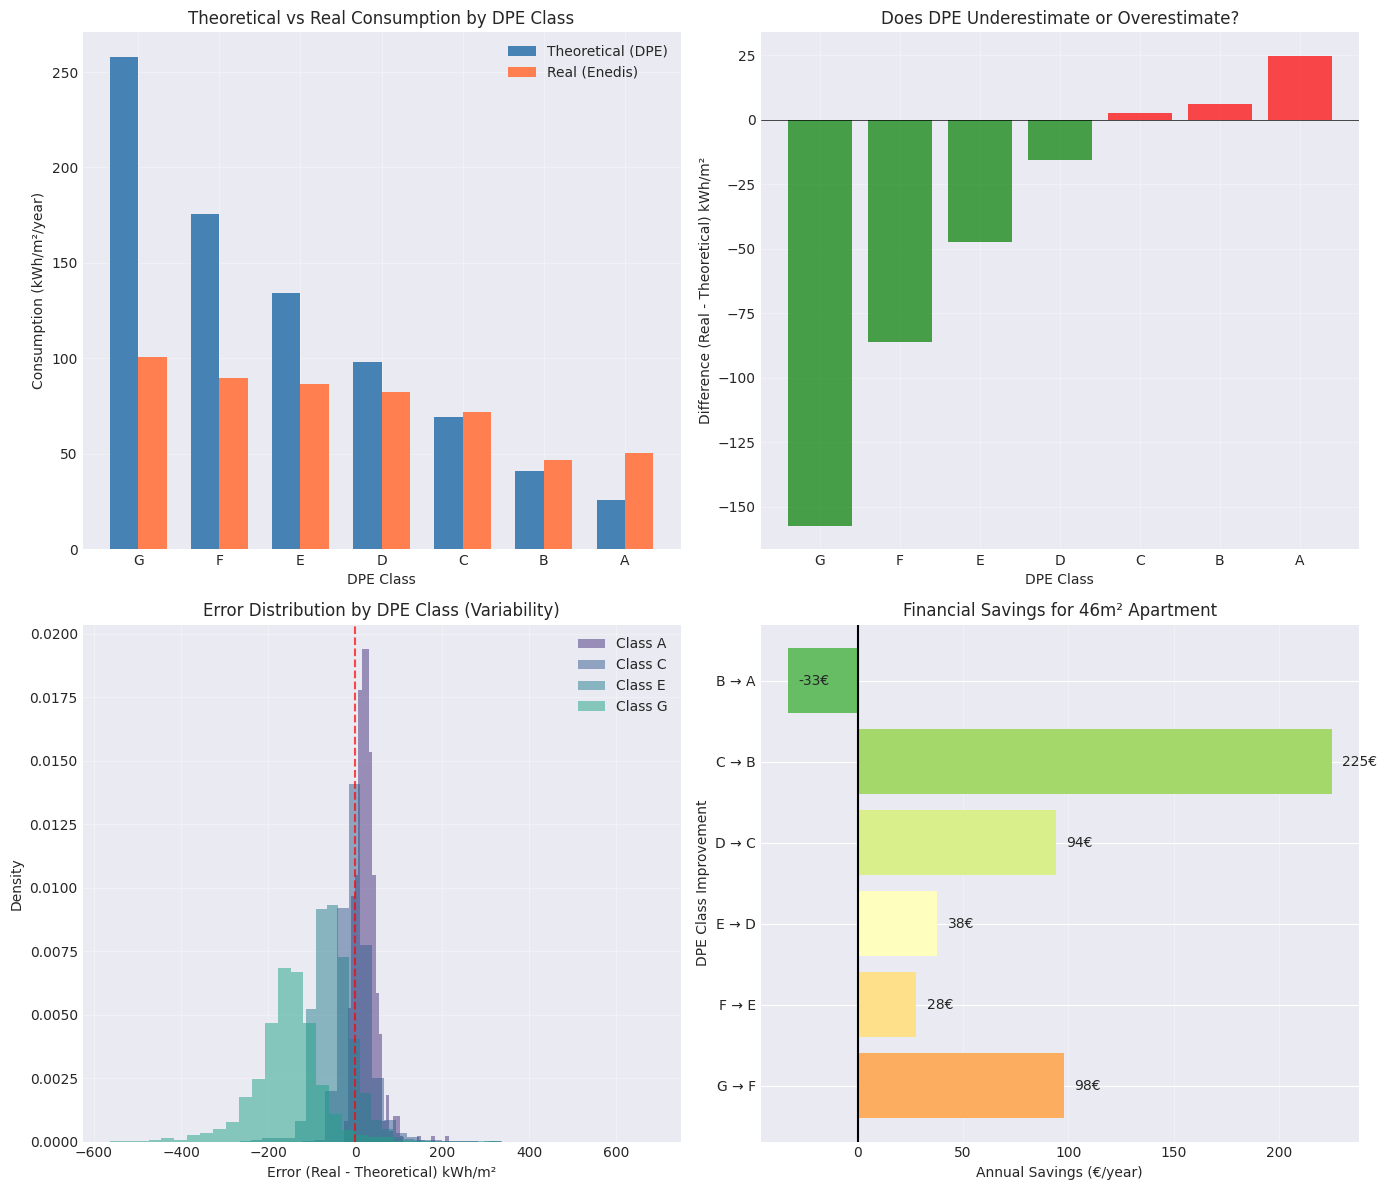

Figure saved as 'dpe_analysis_results.png'


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Theoretical vs Real by DPE Class
ax = axes[0, 0]
x = np.arange(len(class_order))
width = 0.35
theoretical_vals = [consumption_by_class.loc[c, 'consumption_theoretical'] if c in consumption_by_class.index else 0 for c in class_order]
real_vals = [consumption_by_class.loc[c, 'consumption_real'] if c in consumption_by_class.index else 0 for c in class_order]

ax.bar(x - width/2, theoretical_vals, width, label='Theoretical (DPE)', color='steelblue')
ax.bar(x + width/2, real_vals, width, label='Real (Enedis)', color='coral')
ax.set_xlabel('DPE Class')
ax.set_ylabel('Consumption (kWh/m²/year)')
ax.set_title('Theoretical vs Real Consumption by DPE Class')
ax.set_xticks(x)
ax.set_xticklabels(class_order)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Difference by Class
ax = axes[0, 1]
differences = [consumption_by_class.loc[c, 'consumption_real'] - consumption_by_class.loc[c, 'consumption_theoretical'] if c in consumption_by_class.index else 0 for c in class_order]
colors = ['red' if d > 0 else 'green' for d in differences]
ax.bar(class_order, differences, color=colors, alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('DPE Class')
ax.set_ylabel('Difference (Real - Theoretical) kWh/m²')
ax.set_title('Does DPE Underestimate or Overestimate?')
ax.grid(True, alpha=0.3)

# Plot 3: Error Distribution
ax = axes[1, 0]
for dpe_class in ['A', 'C', 'E', 'G']:
    if dpe_class in df['dpe_class'].values:
        subset = df[df['dpe_class'] == dpe_class]['difference'].dropna()
        if len(subset) > 0:
            ax.hist(subset, bins=30, alpha=0.5, label=f'Class {dpe_class}', density=True)
ax.set_xlabel('Error (Real - Theoretical) kWh/m²')
ax.set_ylabel('Density')
ax.set_title('Error Distribution by DPE Class (Variability)')
ax.legend()
ax.axvline(x=0, color='red', linestyle='--', alpha=0.7)
ax.grid(True, alpha=0.3)

# Plot 4: Euro Savings - CORRECTED: 'Improvement' instead of 'Transition'
ax = axes[1, 1]
improvements = df_savings['Improvement'].values
savings_euros = [row['Saving (kWh/m²)'] * median_surface * TARIFF_BASE for _, row in df_savings.iterrows()]
colors_savings = plt.cm.RdYlGn(np.linspace(0.3, 0.8, len(savings_euros)))
ax.barh(improvements, savings_euros, color=colors_savings)
ax.set_xlabel('Annual Savings (€/year)')
ax.set_ylabel('DPE Class Improvement')
ax.set_title(f'Financial Savings for {median_surface:.0f}m² Apartment')
ax.axvline(x=0, color='black')
ax.grid(True, alpha=0.3, axis='x')

for i, v in enumerate(savings_euros):
    ax.text(v + 5, i, f'{v:.0f}€', va='center')

plt.tight_layout()
plt.savefig('dpe_analysis_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as 'dpe_analysis_results.png'")

## Interpretations

**Chart 1: Theoretical vs Real Consumption by DPE Class**
This side-by-side bar chart exposes a critical decoupling between structural thermodynamic modeling and empirical reality. While the theoretical DPE baseline (blue) exhibits a steep, linear decline from Class G (~260 $kWh/m^2/year$) down to Class A (~25 $kWh/m^2/year$), the real consumption tracked by Enedis (orange) displays a far more compressed, non-linear distribution. Real-world consumption barely shifts between Classes G and D, remaining stubbornly anchored around 80–100 $kWh/m^2/year$, and then paradoxically increases for Class A. This demonstrates that the physical characteristics of buildings are consistently buffered—and in some cases overwritten—by actual consumer habits, preventing theoretical optimizations from automatically translating into equivalent empirical drops.

**Chart 2: Does DPE Underestimate or Overestimate?** This diverging bar chart quantifies the directional bias of regulatory energy audits, illustrating a stark 'Prebound vs. Rebound' cross-over point. For energy-inefficient properties (Classes G, F, E, and D), the bars plunge into negative territory, revealing that the DPE massively overestimates consumption—by an outstanding 150 $kWh/m^2$ in Class G alone. Conversely, for highly efficient properties (Classes C, B, and A), the bars cross the zero-axis, showing that the model underestimates real grid demand. This systematic skew proves that lower-income households in inefficient buildings practice forced energy sobriety (prebound effect) due to high costs, whereas occupants in efficient buildings consume more than predicted because the financial penalty of energy use has been minimized. 

**Chart 3: Error Distribution by DPE Class**
This error distribution histogram highlights how behavioral variance and data uncertainty scale inversely with a building's energy efficiency. For Class A (purple) and Class C (blue), the density curves are tightly grouped, highly leptokurtic, and centered near zero, indicating that modern or retrofitted structures provide highly predictable energy outcomes. In sharp contrast, Class G (green) and Class E (teal) display heavily flattened, platykurtic curves with extensive negative tails stretching down to -500 $kWh/m^2$. This severe dispersion demonstrates that as a building’s thermal envelope degrades, the human element becomes the wild card: individual habits, microclimates, and financial constraints cause identical physical structures to yield vastly erratic real-world consumption profiles.

**Chart 4: Financial Savings for a $46m^2$ Apartment** 
This horizontal bar chart translates thermodynamic differentials into tangible economic impacts for a standard $46m^2$ French apartment. The visualization confirms a non-linear return on investment for energetic retrofits. Eradicating the worst-performing 'passoires' via a G-to-F transition yields immediate financial relief of €98/year, yet intermediate upgrades (F to D) hit a structural plateau where savings dry up to just €28–€38/year due to occupants re-adjusting comfort levels. The financial 'jackpot' is unlocked in the C-to-B jump, capturing a massive €225/year savings that underscores the game-changing impact of deep electrification, such as installing air-source heat pumps. Finally, the negative €33/year return for B-to-A upgrades visually seals the behavioral paradox, proving that moving into a theoretically flawless home can trigger a psychological relaxation of energy sobriety."